In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from falsb4mpa.dataset.utils import bucket
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

# Reading data

In [2]:
data = pd.read_csv("../../../data/processed/compas/compas_mpa_bin_wout_agg.csv", index_col=0)

In [3]:
data.head()

,sex,race,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,is_recid,is_violent_recid,two_year_recid,high_risk
id,,,,,,,,,,,,
1,1,0,0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0
3,1,0,0,0.0,0.000000,0.000000,0.000000,0,1,1,1,0
4,1,0,1,0.0,0.000000,0.058824,0.105263,0,1,0,1,0
5,1,0,1,0.0,0.076923,0.000000,0.026316,0,0,0,0,1
6,1,0,0,0.0,0.000000,0.000000,0.052632,0,0,0,0,0


In [4]:
data.duplicated().sum()

np.int64(5524)

In [5]:
print(data.columns)

Index(['sex', 'race', 'age', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'priors_count', 'c_charge_degree', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'high_risk'],
      dtype='object')


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7214 entries, 1 to 11001
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               7214 non-null   int64  
 1   race              7214 non-null   int64  
 2   age               7214 non-null   int64  
 3   juv_fel_count     7214 non-null   float64
 4   juv_misd_count    7214 non-null   float64
 5   juv_other_count   7214 non-null   float64
 6   priors_count      7214 non-null   float64
 7   c_charge_degree   7214 non-null   int64  
 8   is_recid          7214 non-null   int64  
 9   is_violent_recid  7214 non-null   int64  
 10  two_year_recid    7214 non-null   int64  
 11  high_risk         7214 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 732.7 KB


In [7]:
data.isna().sum()

sex                 0
race                0
age                 0
juv_fel_count       0
juv_misd_count      0
juv_other_count     0
priors_count        0
c_charge_degree     0
is_recid            0
is_violent_recid    0
two_year_recid      0
high_risk           0
dtype: int64

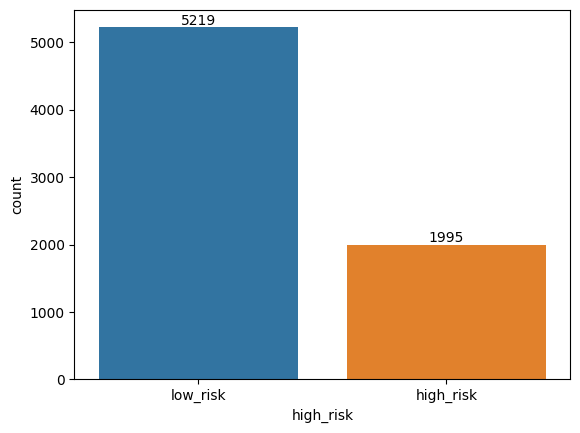

In [8]:
cols = ['high_risk', 'count']
risk = ['low_risk', 'high_risk']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = data['high_risk'].value_counts()
train_df = pd.DataFrame(
    data=[
        [risk[0], train_counts[0]],
        [risk[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='high_risk',y='count',data=res_df,hue='high_risk', dodge=False)
# plt.legend(bbox_to_anchor=(1.25,1.02), loc="upper right")
plt.legend([], frameon=False)
plt.show()

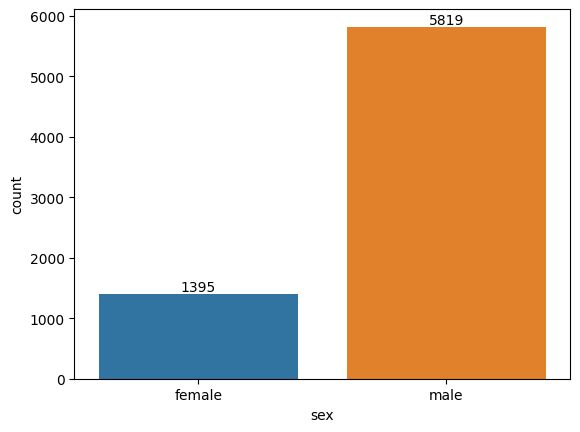

In [9]:
sex_series = data['sex']
cols = ['sex', 'count']
sex = ['female', 'male']
res_df = pd.DataFrame(columns=cols, dtype='object')

train_counts = sex_series.value_counts()
train_df = pd.DataFrame(
    data=[
        [sex[0], train_counts[0]],
        [sex[1], train_counts[1]]
    ],
    columns=cols
)

res_df = pd.concat([train_df])

for i in res_df.index:
    count = res_df.loc[i, 'count']
    y = res_df.loc[i, 'count']
    plt.annotate(count, (i, y), ha="center", va="bottom")

sns.barplot(x='sex',y='count',data=res_df,hue='sex', dodge=False)
# plt.legend(loc="upper right")
plt.legend([], frameon=False)
plt.show()


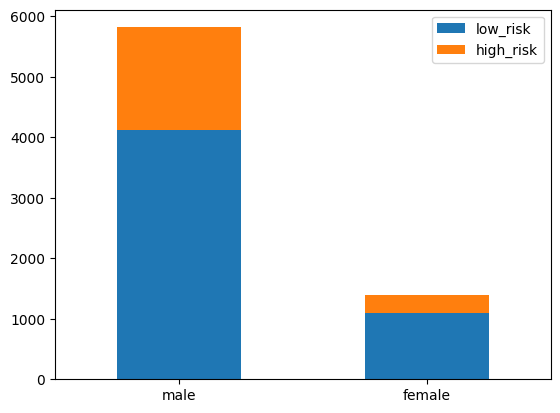

In [10]:
good = data[data['high_risk'] == 1]
man_good = len(good[good['sex'] == 1].index)
woman_good = len(good[good['sex'] == 0].index)

bad = data[data['high_risk'] == 0]
man_bad = len(bad[bad['sex'] == 1].index)
woman_bad = len(bad[bad['sex'] == 0].index)


res_df = pd.DataFrame(
    {
        'low_risk': [man_bad, woman_bad],
        'high_risk': [man_good, woman_good],
    },
    index=['male', 'female']
)

res_df.plot(kind='bar', stacked=True)#, color=['red', 'pink'])
plt.legend(loc="upper right")
plt.xticks(rotation=0)
plt.show()

In [17]:
race_cols = [
    'race_African-American',
    'race_Asian',
    'race_Caucasian',
    'race_Hispanic',
    'race_Native American',
    'race_Other'
]

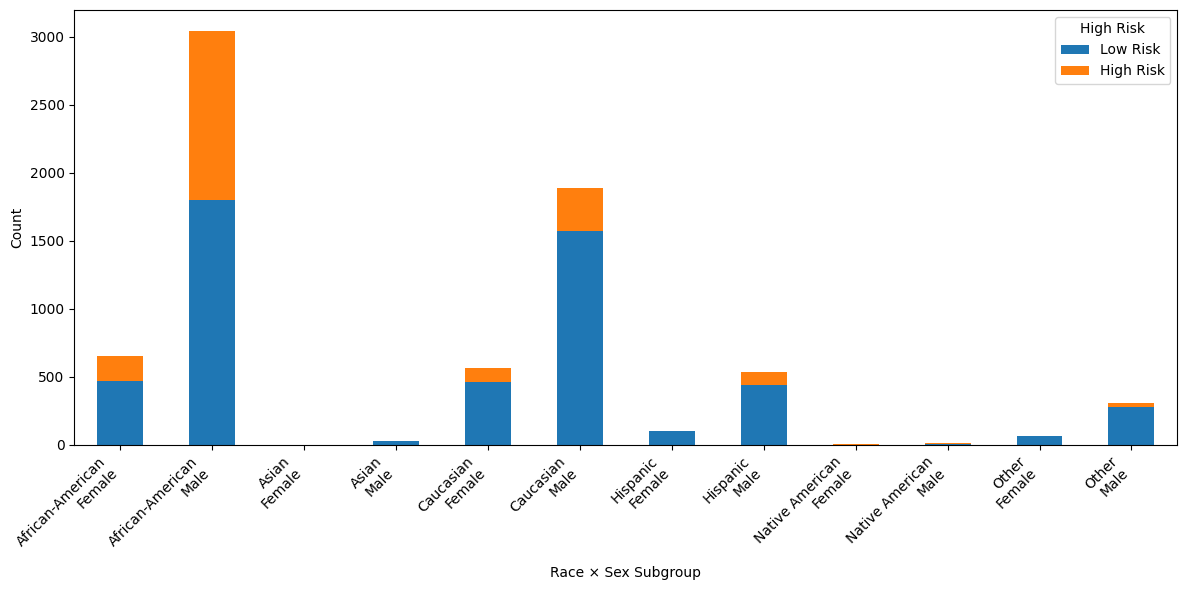

In [18]:
# Recover race category from one-hot encoding
data['race_group'] = (
    data[race_cols]
    .idxmax(axis=1)
    .str.replace('race_', '', regex=False)
)

# Create intersectional subgroup: Race × Sex
data['group'] = (
    data['race_group']
    + '\n' +
    data['sex'].map({
        0: 'Female',
        1: 'Male'
    })
)

# Count risk values within each subgroup
risk_dist = (
    data.groupby(['group', 'high_risk'])
        .size()
        .unstack(fill_value=0)
)

# Ensure both risk classes exist
risk_dist = risk_dist.reindex(columns=[0, 1], fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

risk_dist.plot(
    kind='bar',
    stacked=True,
    ax=ax
)

ax.set_xlabel('Race × Sex Subgroup')
ax.set_ylabel('Count')
ax.legend(title='High Risk', labels=['Low Risk', 'High Risk'])

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Race

In [12]:
data = pd.read_csv("../../../data/processed/compas/compas_mpa_cat_wout_agg.csv")

In [13]:
data.columns

Index(['id', 'sex', 'race_African-American', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Native American', 'race_Other',
       'age_cat_25 - 45', 'age_cat_Greater than 45', 'age_cat_Less than 25',
       'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
       'c_charge_degree', 'is_recid', 'is_violent_recid', 'two_year_recid',
       'high_risk'],
      dtype='object')

In [ ]:
data[['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']].sum()

race_African-American    3696
race_Asian                 32
race_Caucasian           2454
race_Hispanic             637
race_Native American       18
race_Other                377
dtype: int64

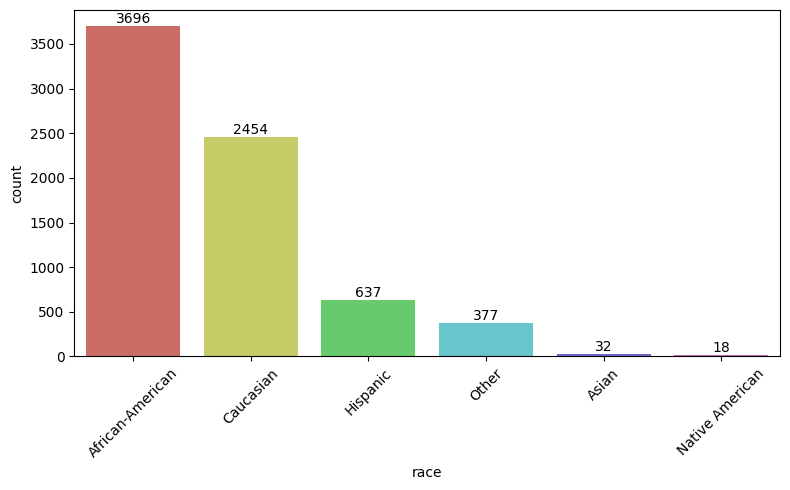

In [15]:
raw_subset = data[['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']]
subset = raw_subset.idxmax(axis=1).str.replace('race_', '', regex=False)

res_df = (
    subset.value_counts()
          .reset_index()
)

res_df.columns = ['race', 'count']

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=res_df,
    x='race',
    y='count',
    hue='race',
    dodge=False,
    palette='hls'
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.legend([], frameon=False)
plt.tight_layout()
plt.show()

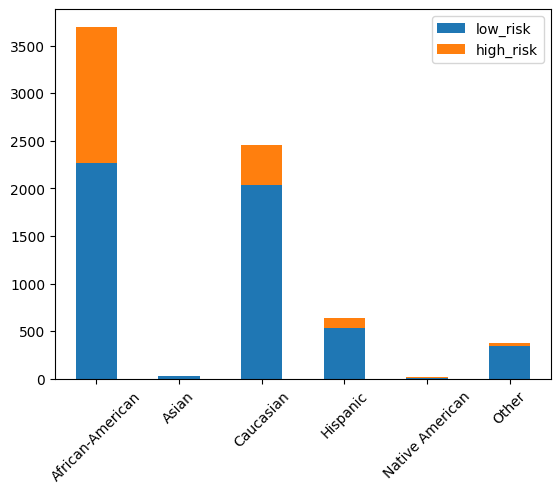

In [16]:
cols = ['race', 'count', 'high_risk']
races = ['African-American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other']
res_df = pd.DataFrame(columns=cols, dtype=object)

great_income = data[data['high_risk'] == 1]
raw_subset = great_income[['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('race_', '')

races_great = subset.value_counts()

low_income = data[data['high_risk'] == 0]
raw_subset = low_income[['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('race_', '')

races_low = subset.value_counts()

res_df = pd.DataFrame(
    {
        'low_risk': races_low,
        'high_risk': races_great,
    },
    index=races
)

res_df.plot(kind='bar', stacked=True)
plt.legend(loc="upper right")
plt.xticks(rotation=45)
plt.show()

In [ ]:
cols = ['race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'count', 'high_risk']
races = ['Female- Amer-Indian-Eskimo', 'Female- Asian-Pac-Islander','Female- Black','Female- Other','Female- White','Male- Amer-Indian-Eskimo','Male- Asian-Pac-Islander','Male- Black','Male- Other','Male- White',]
res_df = pd.DataFrame(columns=cols, dtype=object)

great_income = data[data['income'] == 1]
raw_subset = great_income[['sex-race_ Female- Amer-Indian-Eskimo', 'sex-race_ Female- Asian-Pac-Islander','sex-race_ Female- Black','sex-race_ Female- Other','sex-race_ Female- White','sex-race_ Male- Amer-Indian-Eskimo','sex-race_ Male- Asian-Pac-Islander','sex-race_ Male- Black','sex-race_ Male- Other','sex-race_ Male- White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('sex-race_ ', '')

races_great = subset.value_counts()
# print(races_great)

low_income = data[data['income'] == 0]
raw_subset = low_income[['sex-race_ Female- Amer-Indian-Eskimo', 'sex-race_ Female- Asian-Pac-Islander','sex-race_ Female- Black','sex-race_ Female- Other','sex-race_ Female- White','sex-race_ Male- Amer-Indian-Eskimo','sex-race_ Male- Asian-Pac-Islander','sex-race_ Male- Black','sex-race_ Male- Other','sex-race_ Male- White']]
subset = pd.get_dummies(raw_subset).idxmax(1).str.replace('sex-race_ ', '')

races_low = subset.value_counts()
# print(races_low)

res_df = pd.DataFrame(
    {
        '<=50K': races_low,
        '>50K': races_great,
    },
    index=races
)

res_df.plot(kind='bar', stacked=True)
plt.legend(loc="upper left")
plt.xticks(rotation='vertical')
plt.show()